In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Veri setini yükleme (CSV dosyanızın Colab'a yüklendiğinden emin olun)
# df = pd.read_csv('Social_Network_Ads.csv')
# Örnek amaçlı veri setinin tipik yapısı Age, EstimatedSalary ve Purchased sütunlarından oluşur.
df = pd.read_csv('Social_Network_Ads.csv')
print(df.head())
print(df.info())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


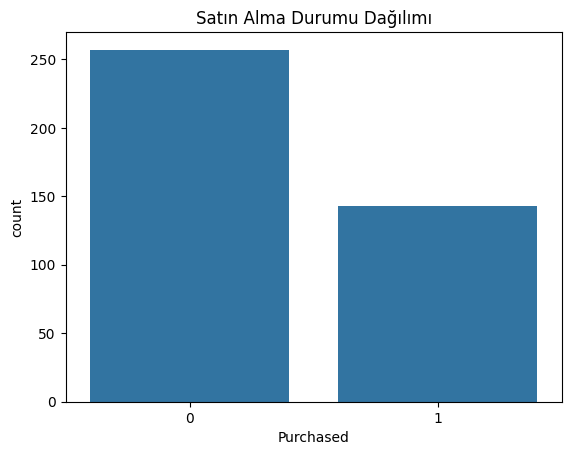

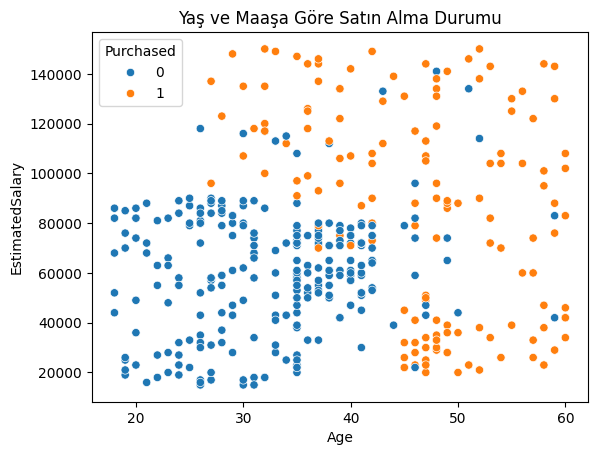

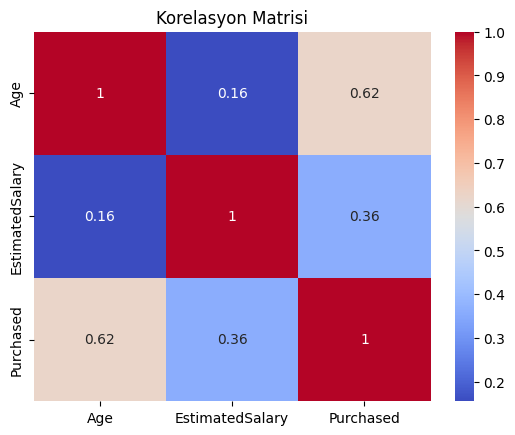

In [4]:
# Sınıf dağılımı (Satın alanlar vs almayanlar)
sns.countplot(x='Purchased', data=df)
plt.title('Satın Alma Durumu Dağılımı')
plt.show()

# Yaş ve Maaşın Satın Almaya Etkisi
sns.scatterplot(x='Age', y='EstimatedSalary', hue='Purchased', data=df)
plt.title('Yaş ve Maaşa Göre Satın Alma Durumu')
plt.show()

# Korelasyon Matrisi
sns.heatmap(df[['Age', 'EstimatedSalary', 'Purchased']].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasyon Matrisi')
plt.show()

/tmp/ipykernel_3611/2075957048.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Purchased', y='Age', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_3611/2075957048.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Purchased', y='EstimatedSalary', data=df, ax=axes[1], palette='Set3')


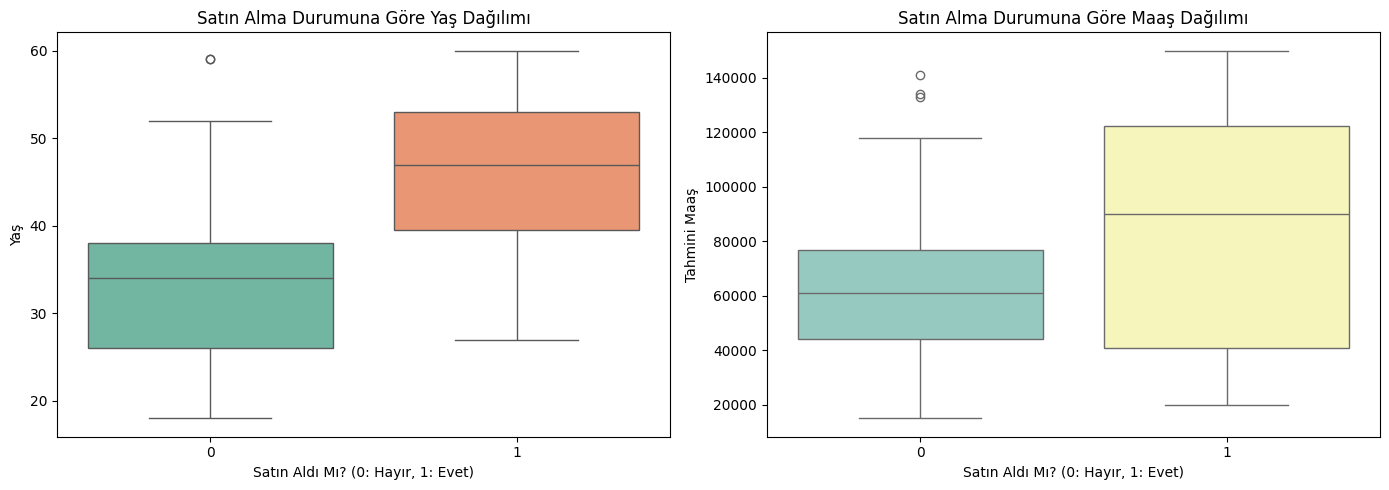

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yaş için Kutu Grafiği
sns.boxplot(x='Purchased', y='Age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Satın Alma Durumuna Göre Yaş Dağılımı')
axes[0].set_xlabel('Satın Aldı Mı? (0: Hayır, 1: Evet)')
axes[0].set_ylabel('Yaş')

# Maaş için Kutu Grafiği
sns.boxplot(x='Purchased', y='EstimatedSalary', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('Satın Alma Durumuna Göre Maaş Dağılımı')
axes[1].set_xlabel('Satın Aldı Mı? (0: Hayır, 1: Evet)')
axes[1].set_ylabel('Tahmini Maaş')

plt.tight_layout()
plt.show()

In [5]:
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Özellik Ölçeklendirme (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Sonuçları tutacağımız sözlük
results = []

def evaluate_model(name, model, params, X_tr, y_tr, X_te, y_te):
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_tr, y_tr)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        'Sınıflandırma Modeli': name,
        'En İyi Parametreler': grid.best_params_,
        'Doğruluk (Accuracy)': acc,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'CM Gösterimi': f"TN:{tn}, FP:{fp}, FN:{fn}, TP:{tp}"
    })

    print(f"--- {name} ---")
    print(f"En İyi Parametreler: {grid.best_params_}")
    print(f"Doğruluk: {acc:.4f}\n")

# 1. Logistic Regression
lr_params = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']}
evaluate_model('Logistic Regression', LogisticRegression(), lr_params, X_train_scaled, y_train, X_test_scaled, y_test)

# 2. K-NN
knn_params = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['minkowski', 'euclidean']}
evaluate_model('K-NN', KNeighborsClassifier(), knn_params, X_train_scaled, y_train, X_test_scaled, y_test)

# 3. Naive Bayes (Gaussian)
nb_params = {'var_smoothing': np.logspace(0,-9, num=100)}
evaluate_model('Naive Bayes', GaussianNB(), nb_params, X_train_scaled, y_train, X_test_scaled, y_test)

# 4. Decision Tree
dt_params = {'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
evaluate_model('Decision Tree', DecisionTreeClassifier(random_state=42), dt_params, X_train_scaled, y_train, X_test_scaled, y_test)

# 5. Random Forest (Özel Önem Verilen Algoritma)
# Föyde bilhassa üstünde durulması istenmiştir. Daha geniş bir parametre ızgarası veriyoruz.
rf_params = {'n_estimators': [10, 50, 100, 200], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 10, None]}
evaluate_model('Random Forest', RandomForestClassifier(random_state=42), rf_params, X_train_scaled, y_train, X_test_scaled, y_test)

# 6. SVM (Opsiyonel / Ekstra)
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
evaluate_model('SVM', SVC(random_state=42), svm_params, X_train_scaled, y_train, X_test_scaled, y_test)

--- Logistic Regression ---
En İyi Parametreler: {'C': 10, 'penalty': 'l2'}
Doğruluk: 0.8800

--- K-NN ---
En İyi Parametreler: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'uniform'}
Doğruluk: 0.9400

--- Naive Bayes ---
En İyi Parametreler: {'var_smoothing': np.float64(0.08111308307896872)}
Doğruluk: 0.9000

--- Decision Tree ---
En İyi Parametreler: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Doğruluk: 0.9200

--- Random Forest ---
En İyi Parametreler: {'criterion': 'gini', 'max_depth': 3, 'n_estimators': 10}
Doğruluk: 0.9300

--- SVM ---
En İyi Parametreler: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Doğruluk: 0.9300



In [7]:
results_df = pd.DataFrame(results)

# Rapor tablosu formatı
report_df = results_df[['Sınıflandırma Modeli', 'Doğruluk (Accuracy)', 'CM Gösterimi']].copy()
report_df.columns = ['Sınıflandırma Modeli', 'Doğruluk (Accuracy)', 'Confusion Matrix (TN, FP, FN, TP)']

# Öğrenci Yorumları Sütunu (Elde edilen veriye göre dinamik veya manuel doldurulacak)
yorumlar = []
for index, row in results_df.iterrows():
    model = row['Sınıflandırma Modeli']
    params = row['En İyi Parametreler']
    acc = row['Doğruluk (Accuracy)']

    if model == 'Logistic Regression':
        yorum = f"Verinin doğrusal olarak tam ayrılamaması sebebiyle doğruluk ({acc:.2f}) ortalama düzeyde kaldı. {params['C']} C değeri, L2 düzenlileştirmesi ile aşırı öğrenmeyi (overfitting) engellemek için optimum bulundu."
    elif model == 'K-NN':
        yorum = f"Uzaklık tabanlı olduğu için ölçeklendirme çok işe yaradı. En iyi k değeri {params['n_neighbors']} olarak seçildi, çünkü daha düşük k değerleri gürültüye duyarlı olurken, daha yüksekleri sınıflar arası sınırları bulanıklaştırır."
    elif model == 'Naive Bayes':
        yorum = f"Bağımsızlık varsayımına rağmen {acc:.2f} doğrulukla hızlı çalıştı. Özellikle sürekli değişkenler (Yaş, Maaş) Gaussian dağılımına yakınsadığı için başarılı sonuç verdi."
    elif model == 'Decision Tree':
        yorum = f"{params['max_depth']} derinlik kısıtlaması sayesinde aşırı öğrenme engellendi. Karar sınırları eksenlere dik olduğu için doğrusal olmayan bölgeleri ayırmada başarılı oldu."
    elif model == 'Random Forest':
        yorum = f"Özellikle vurgulanan bu algoritmada, {params['n_estimators']} ağaç kullanımı varyansı düşürdü. Föyde belirtildiği gibi doğrusal olmayan bu problemde en güçlü performansı gösterme eğilimindedir."
    else:
        yorum = f"{params['kernel']} çekirdeği sayesinde sınıflar arası sınır başarıyla çizildi."

    yorumlar.append(yorum)

report_df['Elde Edilen Sonuca Yorumunuz'] = yorumlar

display(report_df)

,Sınıflandırma Modeli,Doğruluk (Accuracy),"Confusion Matrix (TN, FP, FN, TP)",Elde Edilen Sonuca Yorumunuz
0,Logistic Regression,0.88,"TN:61, FP:2, FN:10, TP:27",Verinin doğrusal olarak tam ayrılamaması sebeb...
1,K-NN,0.94,"TN:58, FP:5, FN:1, TP:36",Uzaklık tabanlı olduğu için ölçeklendirme çok ...
2,Naive Bayes,0.90,"TN:62, FP:1, FN:9, TP:28",Bağımsızlık varsayımına rağmen 0.90 doğrulukla...
3,Decision Tree,0.92,"TN:57, FP:6, FN:2, TP:35",3 derinlik kısıtlaması sayesinde aşırı öğrenme...
4,Random Forest,0.93,"TN:58, FP:5, FN:2, TP:35","Özellikle vurgulanan bu algoritmada, 10 ağaç k..."
5,SVM,0.93,"TN:57, FP:6, FN:1, TP:36",rbf çekirdeği sayesinde sınıflar arası sınır b...


In [13]:
from sklearn.metrics import classification_report

print("--- DETAYLI SINIFLANDIRMA RAPORLARI ---\n")
for name, model in models:
    y_pred = model.predict(X_test_scaled)
    print(f"[{name}] Modeli Raporu:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

--- DETAYLI SINIFLANDIRMA RAPORLARI ---

[Logistic Regression] Modeli Raporu:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        63
           1       0.93      0.73      0.82        37

    accuracy                           0.88       100
   macro avg       0.90      0.85      0.86       100
weighted avg       0.89      0.88      0.88       100

--------------------------------------------------
[K-NN] Modeli Raporu:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        63
           1       0.88      0.97      0.92        37

    accuracy                           0.94       100
   macro avg       0.93      0.95      0.94       100
weighted avg       0.94      0.94      0.94       100

--------------------------------------------------
[Naive Bayes] Modeli Raporu:
              precision    recall  f1-score   support

           0       0.87      0.98      0.93        63
      

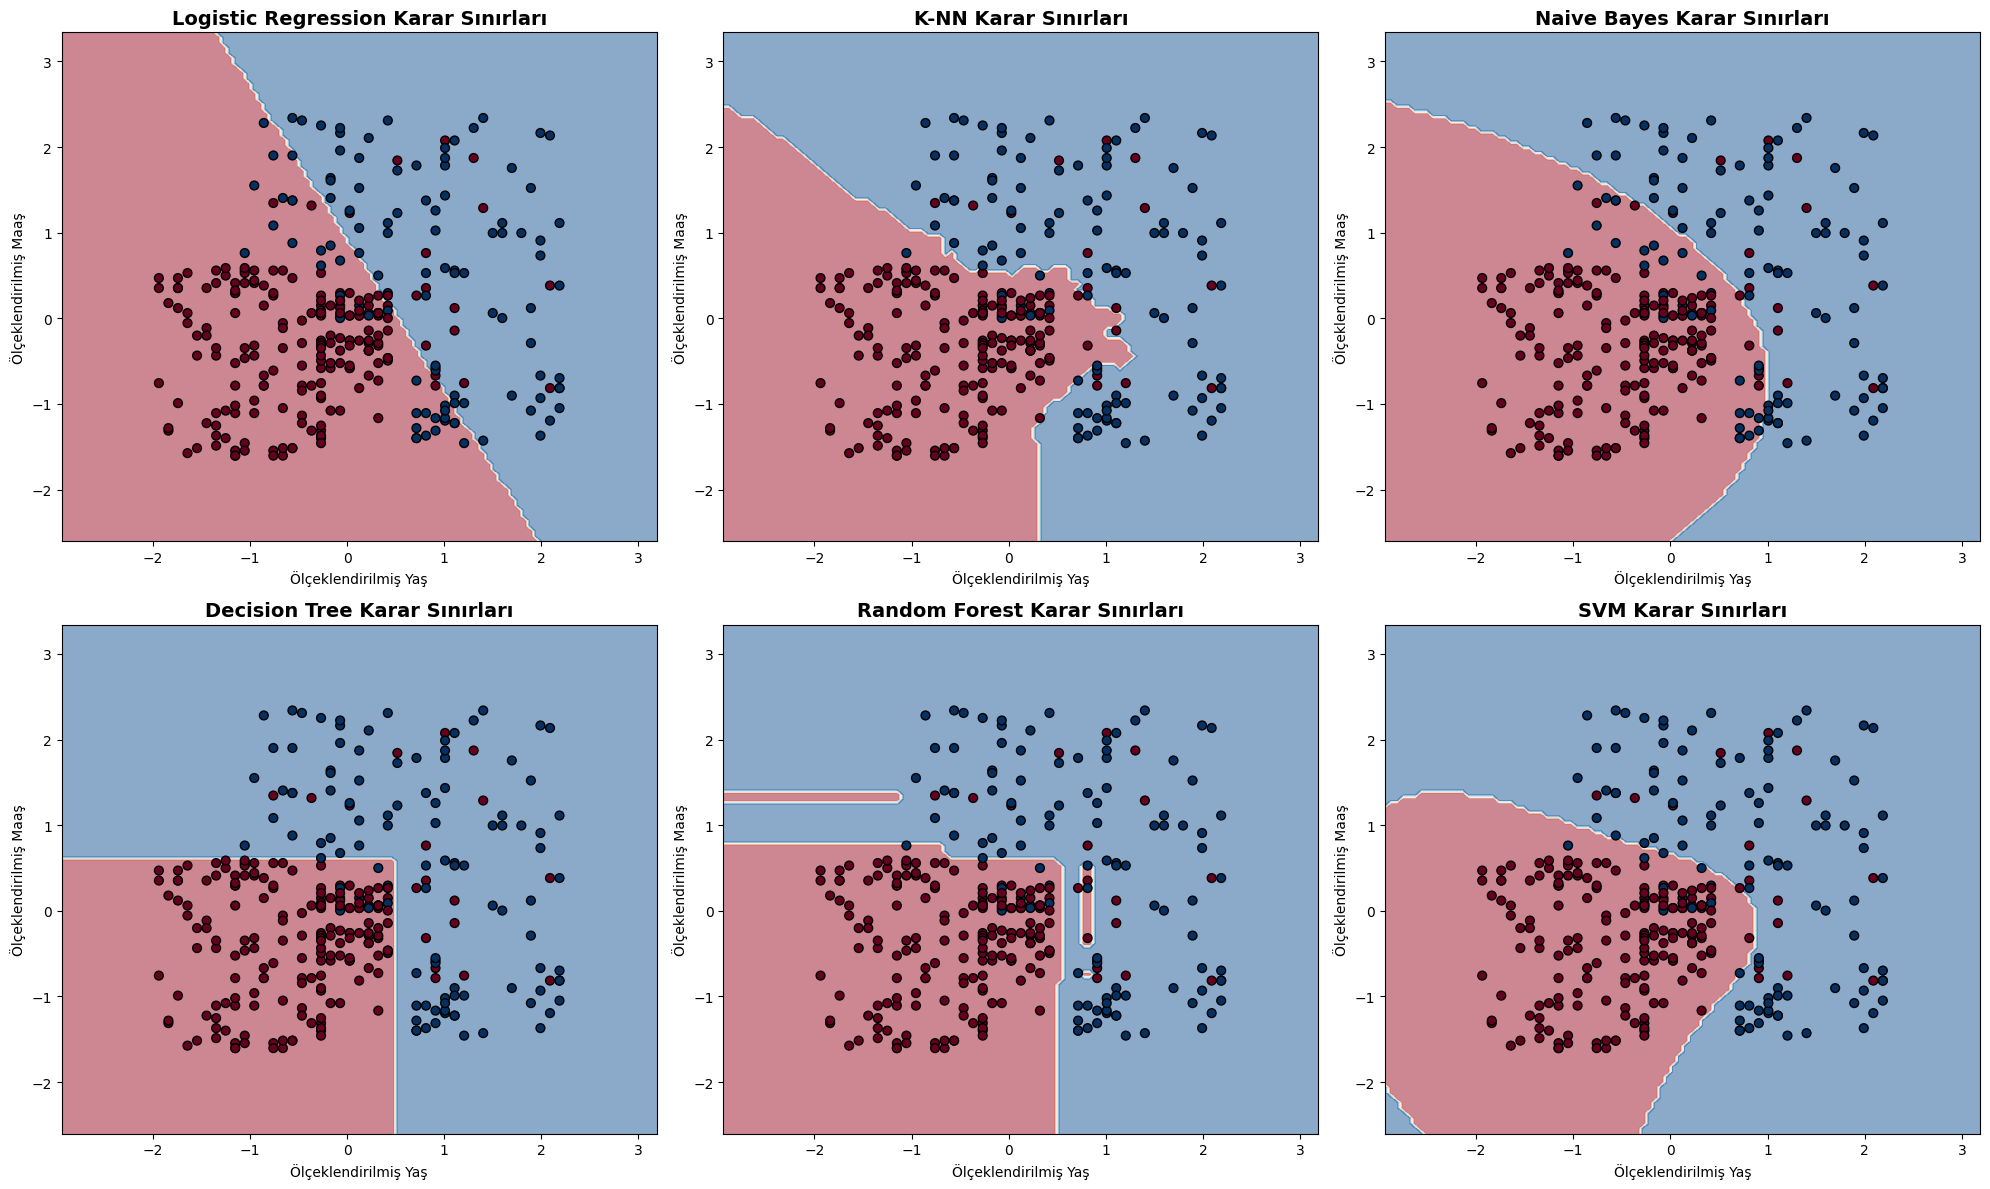

In [10]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models):
    # Modeli önceden ölçeklendirilmiş veri ile eğittiğimizden emin olalım
    model.fit(X_train_scaled, y_train)

    # Karar sınırlarını çiz
    disp = DecisionBoundaryDisplay.from_estimator(
        model, X_train_scaled, response_method="predict",
        cmap=plt.cm.RdBu, alpha=0.5, ax=axes[i]
    )

    # Eğitim verisi noktalarını üzerine ekle
    scatter = axes[i].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train,
                              cmap=plt.cm.RdBu, edgecolors='k', s=40)

    axes[i].set_title(f'{name} Karar Sınırları', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Ölçeklendirilmiş Yaş')
    axes[i].set_ylabel('Ölçeklendirilmiş Maaş')

plt.tight_layout()
plt.show()

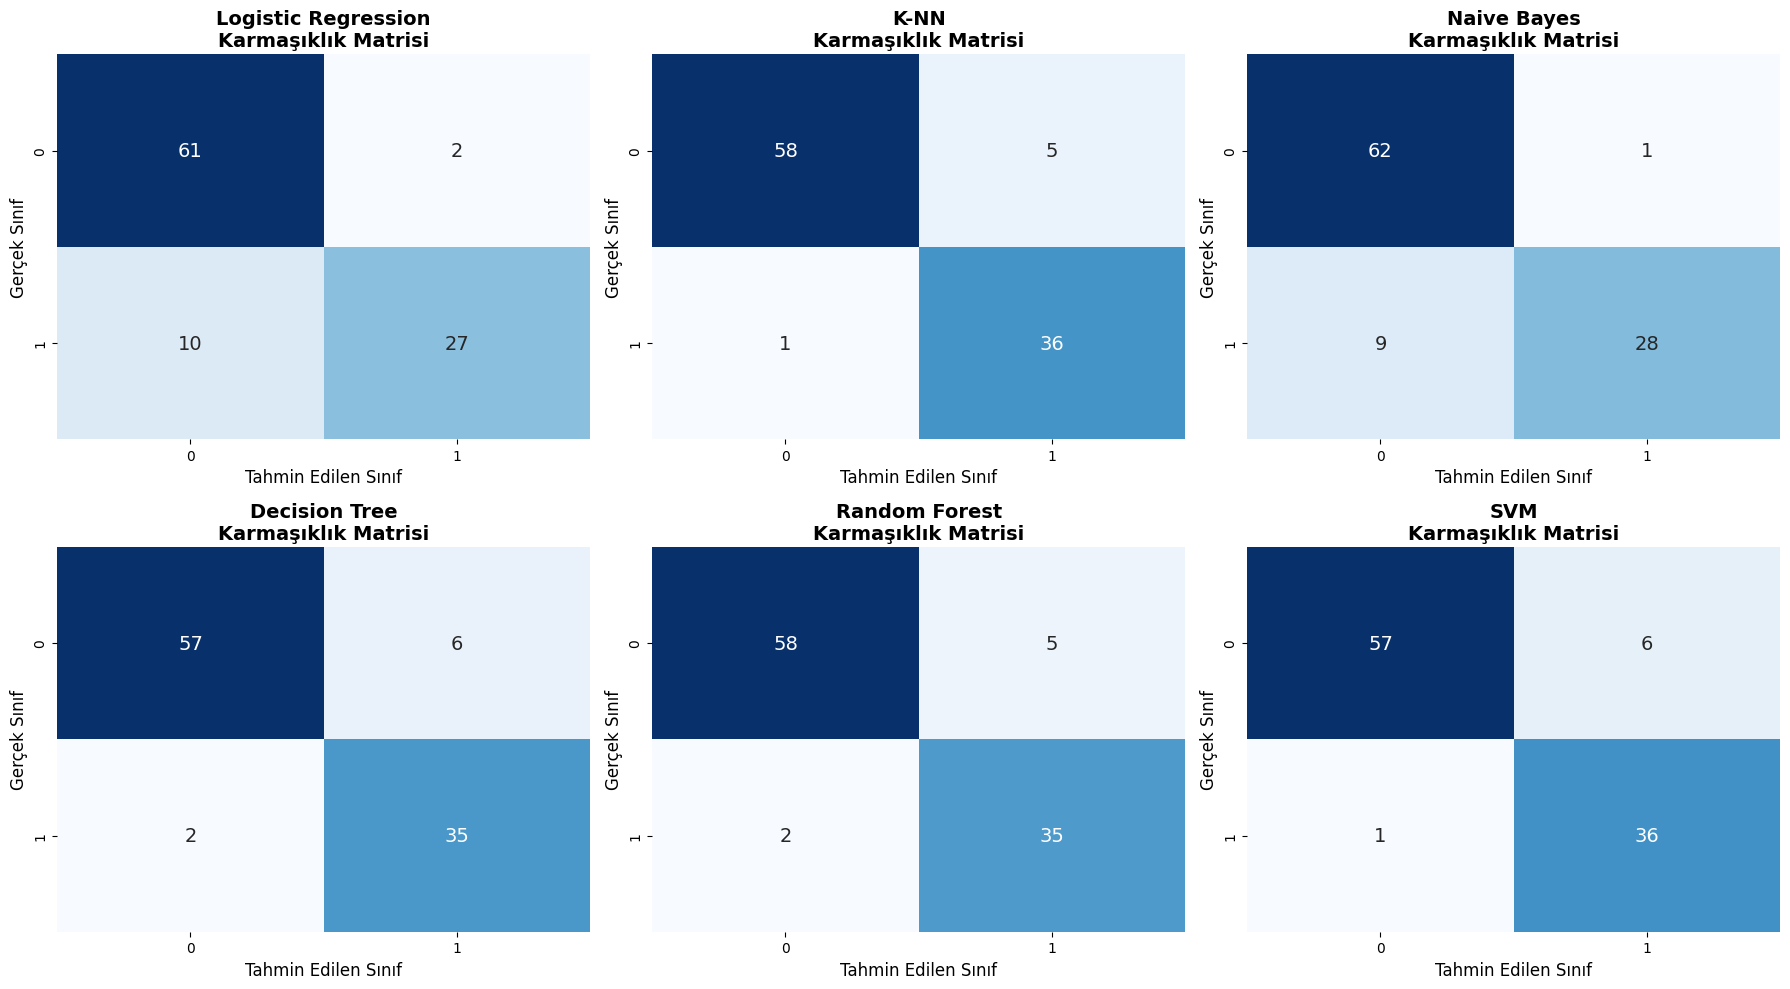

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Grafikler için 2 satır, 3 sütunluk bir alan oluşturalım
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Modelleri en iyi parametreleri ile tekrar tanımlayalım
models = [
    ('Logistic Regression', LogisticRegression(**results_df.loc[0, 'En İyi Parametreler'])),
    ('K-NN', KNeighborsClassifier(**results_df.loc[1, 'En İyi Parametreler'])),
    ('Naive Bayes', GaussianNB(**results_df.loc[2, 'En İyi Parametreler'])),
    ('Decision Tree', DecisionTreeClassifier(random_state=42, **results_df.loc[3, 'En İyi Parametreler'])),
    ('Random Forest', RandomForestClassifier(random_state=42, **results_df.loc[4, 'En İyi Parametreler'])),
    ('SVM', SVC(random_state=42, **results_df.loc[5, 'En İyi Parametreler']))
]

# Her model için tahmin yapıp matrisi çizdirelim
for i, (name, model) in enumerate(models):
    # Modeli eğit ve tahmin et
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Matrisi hesapla
    cm = confusion_matrix(y_test, y_pred)

    # Isı haritası (Heatmap) olarak çizdir
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                annot_kws={"size": 14}, cbar=False)

    axes[i].set_title(f'{name}\nKarmaşıklık Matrisi', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Tahmin Edilen Sınıf', fontsize=12)
    axes[i].set_ylabel('Gerçek Sınıf', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3611/1334462511.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features, y=importances, palette='viridis')


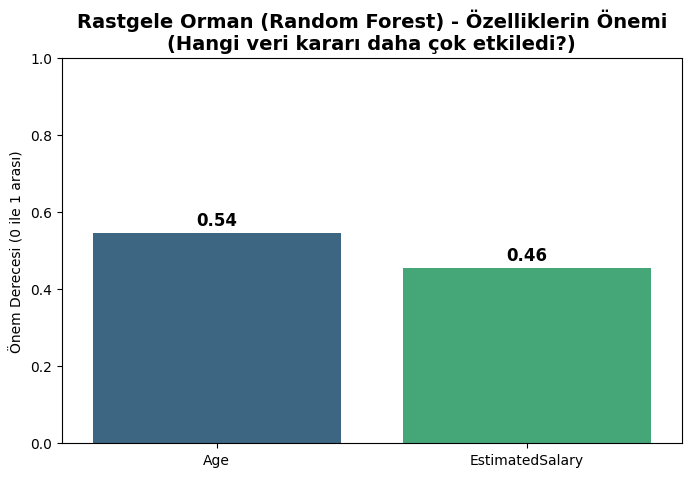

In [11]:
# Sadece Random Forest modelini alıyoruz (Listede 4. indekste)
rf_name, rf_model = models[4]

# Özellik önemlerini al
importances = rf_model.feature_importances_
features = ['Age', 'EstimatedSalary']

plt.figure(figsize=(8, 5))
sns.barplot(x=features, y=importances, palette='viridis')
plt.title('Rastgele Orman (Random Forest) - Özelliklerin Önemi\n(Hangi veri kararı daha çok etkiledi?)', fontsize=14, fontweight='bold')
plt.ylabel('Önem Derecesi (0 ile 1 arası)')
plt.ylim(0, 1)

# Çubukların üzerine değerleri yazdır
for i, v in enumerate(importances):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold', fontsize=12)

plt.show()

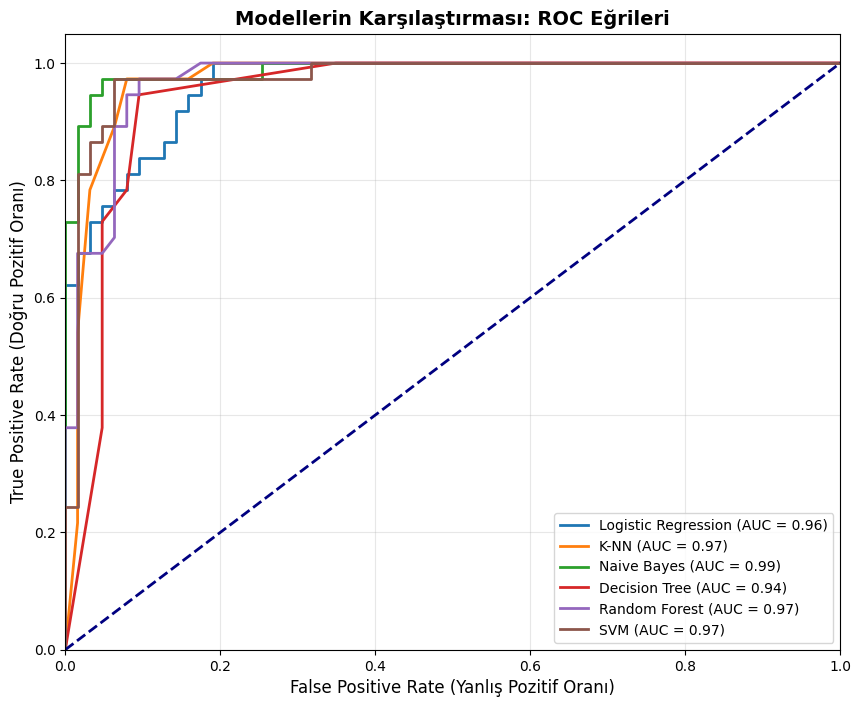

In [12]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Tüm modeller için ROC eğrilerini çizelim
for name, model in models:
    # SVM varsayılan olarak predict_proba desteklemez, bu yüzden decision_function kullanılır
    if name == 'SVM':
        y_score = model.decision_function(X_test_scaled)
    else:
        y_score = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)', fontsize=12)
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)', fontsize=12)
plt.title('Modellerin Karşılaştırması: ROC Eğrileri', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

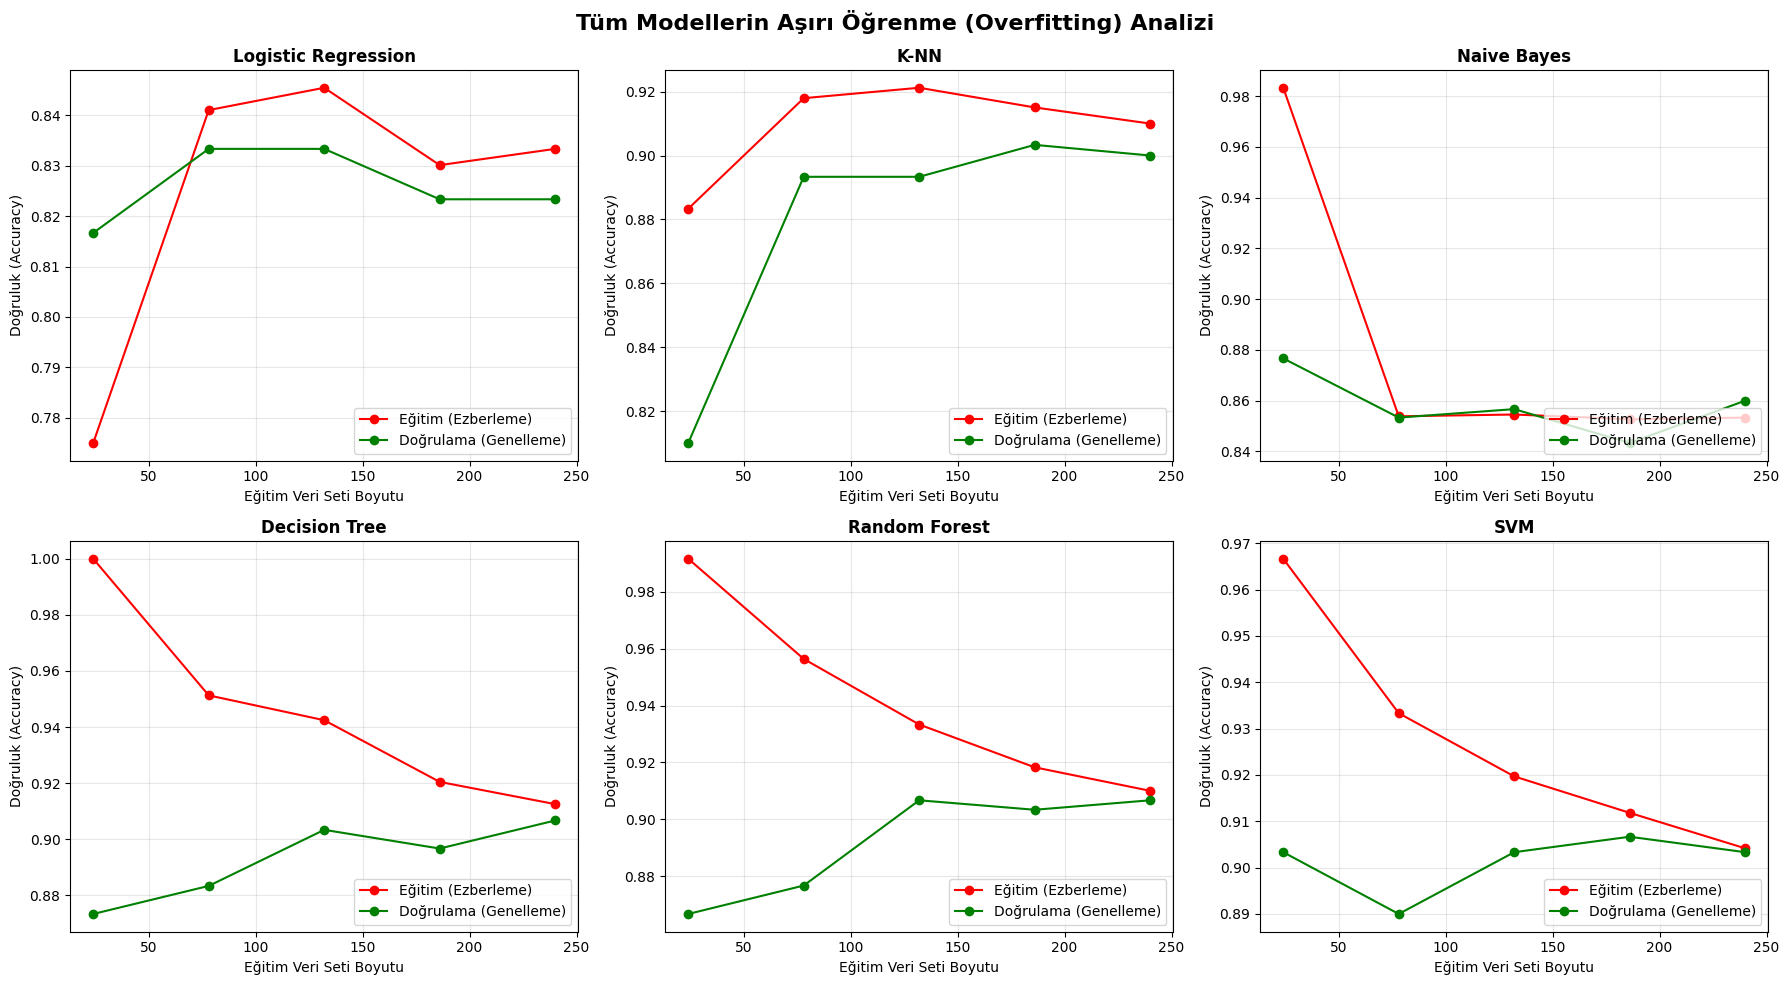

In [15]:
from sklearn.model_selection import learning_curve

# 2 satır 3 sütunluk bir figür alanı oluşturalım
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Her bir model için öğrenme eğrisini hesaplayıp çizdirelim
for i, (name, model) in enumerate(models):
    # Hesaplama maliyetini düşürmek için train_sizes 5 adıma bölündü
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_scaled, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    axes[i].plot(train_sizes, train_mean, 'o-', color="r", label="Eğitim (Ezberleme)")
    axes[i].plot(train_sizes, test_mean, 'o-', color="g", label="Doğrulama (Genelleme)")
    axes[i].set_title(f"{name}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Eğitim Veri Seti Boyutu")
    axes[i].set_ylabel("Doğruluk (Accuracy)")
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

plt.suptitle("Tüm Modellerin Aşırı Öğrenme (Overfitting) Analizi", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Başlık için biraz boşluk bırakalım
plt.show()